#  1. IMPORT LIBRARIES

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim import lr_scheduler

import multiprocessing
import os
import csv
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A
import matplotlib.pyplot as plt
import torch.nn as nn

#  2. CONFIGS

In [ ]:
configs = {
    "folder": "/content/drive/MyDrive/IPSAL/Semi-Supervised/FixMatch", # Folder mẹ
    "folder_data": "/content/drive/MyDrive/IPSAL/dataset/BloodMnist/",
    "dataset": "BloodMnist",                                 # Dataset hiện tại
    "version": "V3_120samples_200epoch",                                    # Tên phiên bản (V0, V1,...)
    "label_data":120,
    "lambda_u":1.0,
    "uratio":1.0-(120.0/ 11959.0) ,                                       # Tỉ lệ (%) số ảnh train không nhãn / tổng số ảnh train
    "train_batch": 32,                                   # Số ảnh trong một train batch của dataloader
    "test_batch": 256,                                    # Số ảnh trong một test batch của dataloader
    "epochs": 00,                                      # Số epochs huấn luyện
    "loss_sup":nn.CrossEntropyLoss()
}

#  3. DATASET & DATALOADER

## *3.1. Load Dataset (NumPy)*

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F # Thêm dòng này để import functional

# Load file .npz từ đường dẫn trong config
data = np.load(configs['folder_data'] + 'bloodmnist_64.npz')

# Lấy dữ liệu train/test
x_train = data['train_images']
y_train = data['train_labels'].squeeze()  # Đảm bảo kích thước (N,)

x_test = data['test_images']
y_test = data['test_labels'].squeeze()


In [ ]:
print(f"Set train có kích thước là: {x_train.shape} tương ứng {x_train.shape[0]} ảnh, {x_train.shape[1]} kênh và kích thước {x_train.shape[2]}px x {x_train.shape[3]}px")
print(f"Set train label có kích thước là: {y_train.shape} tương ứng {y_train.shape[0]} ảnh")
print(f"Set test có kích thước là: {x_test.shape}")
print(f"Set test label có kích thước là: {y_test.shape}")

Set train có kích thước là: (11959, 64, 64, 3) tương ứng 11959 ảnh, 64 kênh và kích thước 64px x 3px
Set train label có kích thước là: (11959,) tương ứng 11959 ảnh
Set test có kích thước là: (3421, 64, 64, 3)
Set test label có kích thước là: (3421,)


## *3.2. Chia Train Dataset thành các tập có/không nhãn*

In [ ]:
x_l, x_u, y_l, y_u = train_test_split(x_train, y_train, train_size = 120, random_state = 42)
'''
_l: tập có nhãn
_u: tập không nhãn
'''
del y_u

In [ ]:
print(f"Set train gắn nhãn (dành cho supervised learning) có kích thước là: {x_l.shape}")
print(f"Set train không nhãn (dành cho unsupervised learning) có kích thước là: {x_u.shape}")

Set train gắn nhãn (dành cho supervised learning) có kích thước là: (120, 64, 64, 3)
Set train không nhãn (dành cho unsupervised learning) có kích thước là: (11839, 64, 64, 3)


## *3.3. Biến đổi - Augmentation*

In [ ]:
MEAN = (0., 0., 0.)
STD = (1., 1., 1.)

In [ ]:
train_transform = A.Compose(
    [
        A.Rotate(limit=20, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Normalize(
            mean = (0., 0., 0.),
            std = (1., 1., 1.),
            max_pixel_value = 255.0
        ),
        A.ToTensorV2(),
    ])

In [ ]:


weak_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.Normalize(mean=MEAN, std=STD, max_pixel_value=255.0),
        A.ToTensorV2(),
    ])




In [ ]:
strong_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.RandomResizedCrop(size=(64, 64), scale=(0.9, 1.0), p=0.7),
    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    A.CoarseDropout(max_holes=1, max_height=4, max_width=4, p=0.3),

    A.Normalize(mean=MEAN, std=STD, max_pixel_value=255.0),
    A.ToTensorV2()
])

/tmp/ipykernel_1175/2734145812.py:6: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=4, max_width=4, p=0.3),


In [ ]:
# strong_transform = A.Compose([
#         A.HorizontalFlip(p=0.5),
#         A.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0), p=1.0),
#         # Chọn ngẫu nhiên các phép biến đổi mạnh
#         A.OneOf([
#             A.AutoContrast(p=1.0),
#             A.Equalize(p=1.0),
#             A.Solarize(threshold=128, p=1.0),
#             A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1, p=1.0),
#             A.Posterize(num_bits=4, p=1.0),
#             A.Sharpen(p=1.0),
#             A.GaussianBlur(blur_limit=(3, 7), p=1.0),
#         ], p=0.7),
#         A.CoarseDropout(max_holes=1, max_height=8, max_width=8, min_holes=1, fill_value=0, p=0.5),

#         A.Normalize(mean=MEAN, std=STD),
#         A.ToTensorV2()
#     ])

In [ ]:
#Chuyển đổi thành Tensor cho tập test
test_transform = A.Compose([
        A.Normalize(mean=MEAN, std=STD,max_pixel_value=255.0),
        A.ToTensorV2(),
    ]
)

In [ ]:
class labeled_dataset(Dataset):
    def __init__(self, img, label, transform):
        self.img = img
        self.label = label
        self.transform = transform
    def __len__(self):
        return len(self.img)
    def __getitem__(self, idx):
        image = self.img[idx]
        label = self.label[idx]

        # NẾU image là tuple (ảnh, nhãn phụ), chỉ lấy phần ảnh
        if isinstance(image, tuple):
            image = image[0]

        # Chuyển đổi sang Numpy nếu đang là Tensor hoặc PIL Image
        if torch.is_tensor(image):
            image = image.permute(1, 2, 0).cpu().numpy()
        elif not isinstance(image, np.ndarray):
            image = np.array(image)

        # Albumentations cần Numpy (H, W, C)
        augmented = self.transform(image=image)
        return augmented['image'], label

In [ ]:
class unlabeled_dataset(Dataset):
    def __init__(self, img, weak_aug, strong_aug):
        self.img = img
        self.weak_aug = weak_aug
        self.strong_aug = strong_aug
    def __len__(self):
        return len(self.img)
    def __getitem__(self, idx):
        image = self.img[idx]

        # Xử lý nếu image là tuple
        if isinstance(image, tuple):
            image = image[0]

        if torch.is_tensor(image):
            image = image.permute(1, 2, 0).cpu().numpy()
        elif not isinstance(image, np.ndarray):
            image = np.array(image)

        weak_img = self.weak_aug(image=image)['image']
        strong_img = self.strong_aug(image=image)['image']

        return strong_img, weak_img

In [ ]:
class test_dataset(Dataset):
    def __init__(self, img, label, transform):
        self.img = img
        self.label = label
        self.transform = transform
    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        image = self.img[idx] # torch.Tensor (C, H, W)
        label = self.label[idx] # torch.Tensor (class label)

        if torch.is_tensor(image):
            image = image.permute(1, 2, 0).cpu().numpy()

        augmented = self.transform(image = image)
        image = augmented['image'] # This will be torch.Tensor (C, H, W)
        return image, label

In [ ]:
l_prepare = labeled_dataset(x_l, y_l, train_transform)
u_prepare = unlabeled_dataset(x_u, weak_transform, strong_transform)
test_prepare = test_dataset(x_test, y_test, test_transform)

## *3.4. Dataloader - Chia về các batch*

In [ ]:
labeled_loader = DataLoader(l_prepare, batch_size = configs["train_batch"], shuffle = True, num_workers = multiprocessing.Pool()._processes)
unlabeled_loader = DataLoader(u_prepare, batch_size = 7*configs["train_batch"], shuffle = True, num_workers = multiprocessing.Pool()._processes)
test_loader = DataLoader(test_prepare, batch_size = configs["test_batch"], shuffle = False, num_workers = multiprocessing.Pool()._processes)

Kích thước ảnh vào: torch.Size([32, 3, 64, 64])
Kích thước ảnh label: torch.Size([32])
Show từng ảnh:


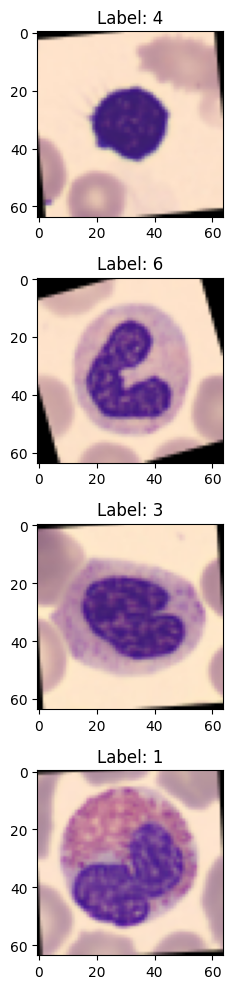

In [ ]:
'''
Kiểm tra xem DataLoader đã chuẩn chưa (Labeled)
'''
check_x, check_y = next(iter(labeled_loader))
print(f"Kích thước ảnh vào: {check_x.shape}")
print(f"Kích thước ảnh label: {check_y.shape}")

print("Show từng ảnh:")
fig, axs = plt.subplots(4,1, figsize=(10, 10))
row = 0
for image_1, label in zip(check_x, check_y):
  if row==4: break
  axs[row].imshow(image_1.permute(1, 2, 0).detach().numpy())
  axs[row].set_title(f"Label: {label}")
  row += 1
plt.tight_layout()
plt.show()

Kích thước ảnh vào: torch.Size([160, 3, 64, 64])
Kích thước ảnh mask: torch.Size([160, 3, 64, 64])
Show từng ảnh:


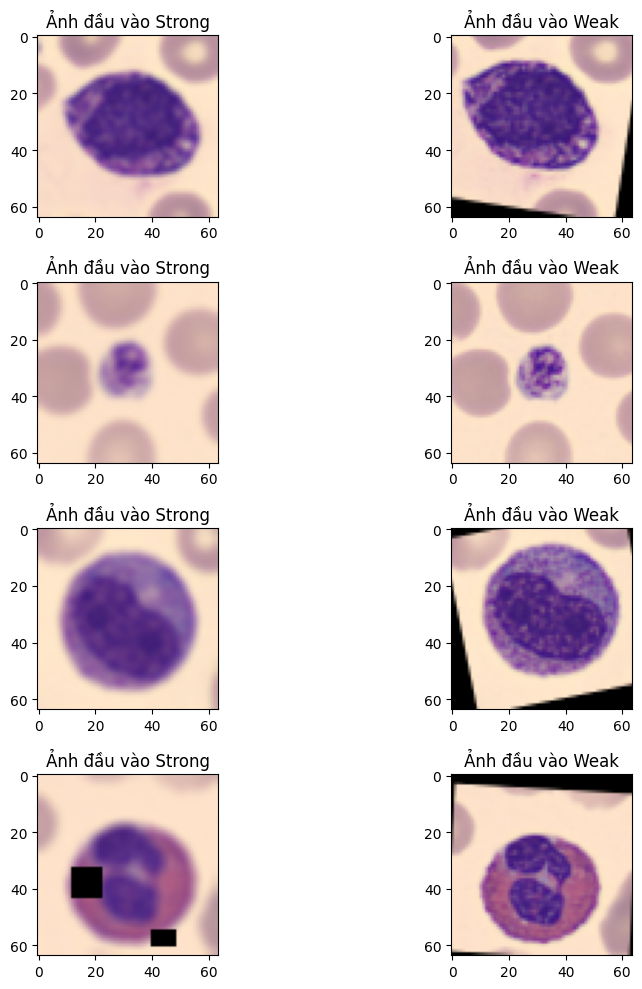

In [ ]:
'''
Kiểm tra xem DataLoader đã chuẩn chưa (Unlabeled)
'''
check_x, check_y = next(iter(unlabeled_loader))
print(f"Kích thước ảnh vào: {check_x.shape}")
print(f"Kích thước ảnh mask: {check_y.shape}")

print("Show từng ảnh:")
fig, axs = plt.subplots(4, 2, figsize=(10, 10))
row = 0
for image_1, image_2 in zip(check_x, check_y):
  if row==4: break
  # image_1 is (H, W, C), so no permute needed
  axs[row, 0].imshow(image_1.cpu().permute(1,2,0).detach().numpy())
  axs[row, 0].set_title("Ảnh đầu vào Strong")
  # image_2 is (C, H, W), so permute to (H, W, C)
  axs[row, 1].imshow(image_2.permute(1, 2, 0).detach().numpy())
  axs[row, 1].set_title("Ảnh đầu vào Weak")
  row += 1
plt.tight_layout()
plt.show()

Kích thước ảnh vào: torch.Size([128, 3, 64, 64])
Kích thước ảnh label: torch.Size([128])
Show từng ảnh:


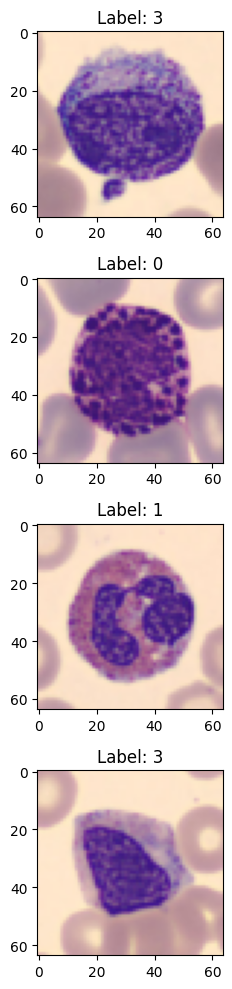

In [ ]:
check_x, check_y = next(iter(test_loader))
print(f"Kích thước ảnh vào: {check_x.shape}")
print(f"Kích thước ảnh label: {check_y.shape}")

print("Show từng ảnh:")
fig, axs = plt.subplots(4,1, figsize=(10, 10))
row = 0
for image_1, label in zip(check_x, check_y):
  if row==4: break
  # image_1 now has shape (C, H, W)
  axs[row].imshow(image_1.permute(1, 2, 0).detach().numpy() )
  axs[row].set_title(f"Label: {label.item()}") # Use .item() for scalar tensor labels
  row += 1
plt.tight_layout()
plt.show()

#  4. BACKBONE

## *4.1. Khối thành phần*

## *4.2. Full Backbone*

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_planes, out_planes, stride, dropRate=0.0):
        super(BasicBlock, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_planes, out_planes, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.droprate = dropRate
        self.equalInOut = (in_planes == out_planes)
        self.convShortcut = (not self.equalInOut) and nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride,
                               padding=0, bias=False) or None
    def forward(self, x):
        if not self.equalInOut:
            x = self.relu1(self.bn1(x))
        else:
            out = self.relu1(self.bn1(x))
        out = self.relu2(self.bn2(self.conv1(out if self.equalInOut else x)))
        if self.droprate > 0:
            out = F.dropout(out, p=self.droprate, training=self.training)
        out = self.conv2(out)
        return torch.add(x if self.equalInOut else self.convShortcut(x), out)

class NetworkBlock(nn.Module):
    def __init__(self, nb_layers, in_planes, out_planes, block, stride, dropRate=0.0):
        super(NetworkBlock, self).__init__()
        self.layer = self._make_layer(block, in_planes, out_planes, nb_layers, stride, dropRate)
    def _make_layer(self, block, in_planes, out_planes, nb_layers, stride, dropRate):
        layers = []
        for i in range(int(nb_layers)):
            layers.append(block(i == 0 and in_planes or out_planes, out_planes, i == 0 and stride or 1, dropRate))
        return nn.Sequential(*layers)
    def forward(self, x):
        return self.layer(x)

class WideResNet(nn.Module):
    def __init__(self, depth, num_classes, widen_factor=1, dropRate=0.0):
        super(WideResNet, self).__init__()
        nChannels = [16, 16*widen_factor, 32*widen_factor, 64*widen_factor]
        assert((depth - 4) % 6 == 0)
        n = (depth - 4) // 6
        block = BasicBlock
        # 1st conv before any network block
        self.conv1 = nn.Conv2d(3, nChannels[0], kernel_size=3, stride=1,
                               padding=1, bias=False)
        # 1st block
        self.block1 = NetworkBlock(n, nChannels[0], nChannels[1], block, 1, dropRate)
        # 2nd block
        self.block2 = NetworkBlock(n, nChannels[1], nChannels[2], block, 2, dropRate)
        # 3rd block
        self.block3 = NetworkBlock(n, nChannels[2], nChannels[3], block, 2, dropRate)
        # global average pooling and classifier
        self.bn1 = nn.BatchNorm2d(nChannels[3])
        self.relu = nn.ReLU(inplace=True)
        self.fc = nn.Linear(nChannels[3], num_classes)
        self.nChannels = nChannels[3]

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.bias.data.zero_()
    def forward(self, x):
        out = self.conv1(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.relu(self.bn1(out))
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(out.size(0), -1)
        return self.fc(out)

#  5. METRIC & LOSS

## *5.1. Metric*

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [ ]:
#Check legit (kind of):
temp = torch.rand(4, 1, 256, 256) > 0.5
temp = temp.float()
temp=temp.view(-1).cpu().numpy()

print(f"Precision: {precision_score(temp, temp)}")
print(f"Recall: {recall_score(temp, temp)}")
print(f"F1-score: {f1_score(temp, temp)}")
print(f"Accuraacy: {accuracy_score(temp, temp)}")

Precision: 1.0
Recall: 1.0
F1-score: 1.0
Accuraacy: 1.0


## *5.2. Loss*

In [ ]:
loss_sup=configs["loss_sup"]

In [ ]:
def loss_con(y_pred_strong, y_pred_weak, threshold):
    probs = torch.softmax(y_pred_weak, dim=1)
    max_probs, targets = torch.max(probs, dim=1)

    mask = max_probs.ge(threshold).float()

    loss = F.cross_entropy(y_pred_strong, targets, reduction='none')
    loss = (loss * mask).sum() / (mask.sum() + 1e-6)  # FIX quan trọng

    return loss

#  6. TRAIN***

## *6.1. Thiết lập Mô hình*

In [ ]:
model = WideResNet(depth=28, num_classes = 8, widen_factor=2,dropRate=0.4)
ema_model = copy.deepcopy(model)
for param in ema_model.parameters():
    param.requires_grad = False

## *6.2. Thiết lập Optimizer và Scheduler*

In [ ]:

optimizer = optim.SGD(model.parameters(), lr=0.03, momentum=0.9, nesterov=True, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                      T_max = configs["epochs"],
                                                      eta_min = 1e-6)

## *6.3. Thiết lập EMA*

In [ ]:
def ema(student, teacher, alpha=0.999):
    for p_s, p_t in zip(student.parameters(), teacher.parameters()):
        p_t.data.mul_(alpha).add_(p_s.data, alpha=1 - alpha)

## *6.4. Các hàm kiểm tra, xuất kết quả*

In [ ]:
def validation(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for image, label in loader:
            image, label = image.to(device), label.to(device)
            pred = model(image)
            _, predicted_classes = torch.max(pred, 1) # Lấy class có xác suất cao nhất

            all_preds.extend(predicted_classes.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Tính toán metrics dùng mảng 1D
    results = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, average='macro', zero_division=0),
        "recall": recall_score(all_labels, all_preds, average='macro', zero_division=0),
        "f1_score": f1_score(all_labels, all_preds, average='macro', zero_division=0)
    }
    return results

In [ ]:
def export_checkpoint(model, dice_string,
                   folder_path, dataset_name,
                   version, uratio, previous_checkpoint = None
                   ):

    if not os.path.exists(f"{folder_path}Weights/{version}/"):
        os.makedirs(f"{folder_path}Weights/{version}/")

    if previous_checkpoint is not None:
        os.remove(previous_checkpoint)

    checkpoint_path = f"{folder_path}/Weights/[CHECKPOINT]_{version}_{dataset_name}_{uratio}U_{dice_string}_dice.pth"
    torch.save(model.state_dict(), checkpoint_path)
    return checkpoint_path

In [ ]:
def export_history(epoch,
                   folder_path,
                   version,
                   dataset_name,
                   uratio,
                   sup_loss, con_loss,
                   val_accuracy, val_precision,
                   val_recall, val_f1_score,
                   ):
    if not os.path.exists(f"{folder_path}Weights/{version}/"):
        os.makedirs(f"{folder_path}Weights/{version}/")
    fields = ["epoch", "sup_loss", "con_loss", "val_accuracy",
              "val_precision", "val_recall", "val_f1_score"]
    with open(f"{folder_path}/Weights/[HISTORY]_{version}_{dataset_name}_{uratio}U.csv", "a") as f:
        writer = csv.writer(f)
        if epoch == 0:
            writer.writerow(fields)
        writer.writerow([epoch, sup_loss, con_loss, val_accuracy,
                         val_precision, val_recall, val_f1_score])

## *6.5. Training Loop*

In [ ]:
from itertools import cycle

In [ ]:
def training_loop(model,ema_model,
                  optimizer, scheduler,
                  labeled_loader, unlabeled_loader, test_loader,
                  epochs, version, dataset_name, folder_path, uratio
                  ):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    best_acc =0.0
    checkpoint_temp=None
    ema_model.to(device) # Move ema_model to the same device
    for epoch in range(epochs):
        print(f"Epoch: {epoch}")
        print(f"Current lr: {optimizer.param_groups[0]['lr']}")
        model.train()
        train_loader=zip(labeled_loader,cycle(unlabeled_loader))
        pbar=enumerate(zip(labeled_loader, unlabeled_loader))

        running_sup_loss=0.0
        running_con_loss=0.0
        all_preds=[]
        all_labels=[]

        for idx,((inputs_x,targets_x),(inputs_u_strong, inputs_u_weak)) in enumerate(train_loader):
            inputs_x=inputs_x.to(device)
            targets_x=targets_x.to(device)
            inputs_u_strong=inputs_u_strong.to(device)
            inputs_u_weak=inputs_u_weak.to(device)

            logits_x=model(inputs_x)
            logits_u_strong=model(inputs_u_strong)
            with torch.no_grad():
                logits_u_weak=model(inputs_u_weak)
            #Loss-supervised
            sup_loss_val=configs["loss_sup"](logits_x,targets_x)

            #loss-consis
            con_loss_val=loss_con(logits_u_strong,logits_u_weak,threshold=0.95)

            loss=sup_loss_val+configs["lambda_u"]*con_loss_val

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_sup_loss+=sup_loss_val.item()
            running_con_loss+=con_loss_val.item()

            _,preds=torch.max(logits_x,1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(targets_x.cpu().numpy())
        scheduler.step()
        avg_sup_loss=running_sup_loss/(idx+1)
        avg_con_loss=running_con_loss/(idx+1)

        # Concatenate all predictions and labels before calculating metrics
        all_labels_flat = np.concatenate(all_labels)
        all_preds_flat = np.concatenate(all_preds)

        train_accuracy = accuracy_score(all_labels_flat, all_preds_flat)
        train_f1=f1_score(all_labels_flat, all_preds_flat,average='macro', zero_division=0)
        train_precision=precision_score(all_labels_flat, all_preds_flat,average='macro', zero_division=0)
        train_recall=recall_score(all_labels_flat, all_preds_flat,average='macro', zero_division=0)

        print(f"1. Training Phase Results:")
        print(f"\t Sup Loss: {avg_sup_loss:.4f} | Con Loss: {avg_con_loss:.4f} |"
              f"Train Accuracy: {train_accuracy:.4f} | Train F1 Score: {train_f1:.4f}  |"
              f"Train Precision: {train_precision:.4f}  |  Train Recall: {train_recall:.4f}")

        print("2. Validation Phase")
        eval_model=model
        eval_model.eval()


        val_results = validation(eval_model, test_loader, device)

        val_accuracy = val_results["accuracy"]
        val_f1 = val_results["f1_score"]
        val_precision = val_results["precision"]
        val_recall = val_results["recall"]

        print(f"\t Val Accuracy: {val_accuracy: .4f} | Val F1 Score: {val_f1: .4f}"
              f"\t Val Precision: {val_precision: .4f} | Val Recall: {val_recall: .4f}")

        if val_accuracy > best_acc:
            best_acc = val_accuracy
            print("\t Best Val Accuracy up-to-moment")
            print("\t Saving model...")

            val_accuracy_string = f"{val_accuracy:.4f}".replace(".", "_") # Fix: Removed leading space
            checkpoint_temp = export_checkpoint(model = model,
                                             dice_string = val_accuracy_string,
                                             folder_path = folder_path,
                                             dataset_name = dataset_name,
                                             version = version,
                                             uratio = uratio,
                                             previous_checkpoint = None if epoch == 0 else checkpoint_temp,)
        export_history(epoch = epoch,
                       folder_path = folder_path,
                       version = version,
                       dataset_name = dataset_name,
                       uratio = uratio,
                       sup_loss = running_sup_loss,
                       con_loss = running_con_loss,
                       val_accuracy = val_accuracy,
                       val_precision = val_precision,
                       val_recall = val_recall,
                       val_f1_score = val_f1)
        print("\n")

In [ ]:
training_loop(model = model,ema_model=ema_model,
              optimizer = optimizer,
              scheduler = scheduler,
              labeled_loader = labeled_loader,
              unlabeled_loader = unlabeled_loader,
              test_loader = test_loader,
              epochs = configs["epochs"],
              version = configs["version"],
              dataset_name = configs["dataset"],
              folder_path = configs["folder"],
              uratio = configs['uratio'])

Epoch: 0
Current lr: 0.03
1. Training Phase Results:
	 Sup Loss: 2.0961 | Con Loss: 0.0000 |Train Accuracy: 0.1250 | Train F1 Score: 0.0687  |Train Precision: 0.0739  |  Train Recall: 0.1091
2. Validation Phase
	 Val Accuracy:  0.0830 | Val F1 Score:  0.0192	 Val Precision:  0.0104 | Val Recall:  0.1250
	 Best Val Accuracy up-to-moment
	 Saving model...


Epoch: 1
Current lr: 0.02997040191305986
1. Training Phase Results:
	 Sup Loss: 2.0167 | Con Loss: 0.0000 |Train Accuracy: 0.1917 | Train F1 Score: 0.0521  |Train Precision: 0.1485  |  Train Recall: 0.1316
2. Validation Phase
	 Val Accuracy:  0.0830 | Val F1 Score:  0.0192	 Val Precision:  0.0104 | Val Recall:  0.1250


Epoch: 2
Current lr: 0.02988172446236651
1. Training Phase Results:
	 Sup Loss: 1.9938 | Con Loss: 0.0000 |Train Accuracy: 0.2000 | Train F1 Score: 0.0631  |Train Precision: 0.1483  |  Train Recall: 0.1382
2. Validation Phase
	 Val Accuracy:  0.0830 | Val F1 Score:  0.0192	 Val Precision:  0.0104 | Val Recall:  0.1250


KeyboardInterrupt: 